In this notebook, we will try to estimate the parameters of the superposition of two Thomas processes, under two assumptions:
- **Assumption 1**: The tree centers are generated by the same _Poisson_ process; $\lambda_{p,i} = \lambda_{p,j} = \lambda_p$
- **Assumption 2**: The larger the tree, the more offspring nodes we have; $\exists \mu \in \mathbb{R}^+\ \nu_i = \mu \sigma_i^2$

We'll be left with four parameters to estimate: $\theta = (\mu, \lambda_p, \sigma_1, \sigma_2)$

**Imports**

In [49]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import contrast, f4
import json

First, we will generate and display a superposition of such two thomas processes.

In [50]:
with open('../../parameters/superposition-m-12.json', 'r') as file:
    params = json.load(file)

In [51]:
W = params['W']
w, h = W
mu = params['mu']
lam_p = params['lam_p']
sig1, sig2 = params['thomas_1']['sig'], params['thomas_2']['sig']
nu1, nu2 = mu*sig1**2, mu*sig2**2

In [52]:
thomas_process1 = ThomasProcess(lam_p, nu1, sig1)
parents1, points_thomas1 = thomas_process1.generate(W, seed=46)
thomas_process2 = ThomasProcess(lam_p, nu2, sig2)
parents2, points_thomas2 = thomas_process2.generate(W, seed=125)
points_sup = np.concatenate([points_thomas1, points_thomas2])

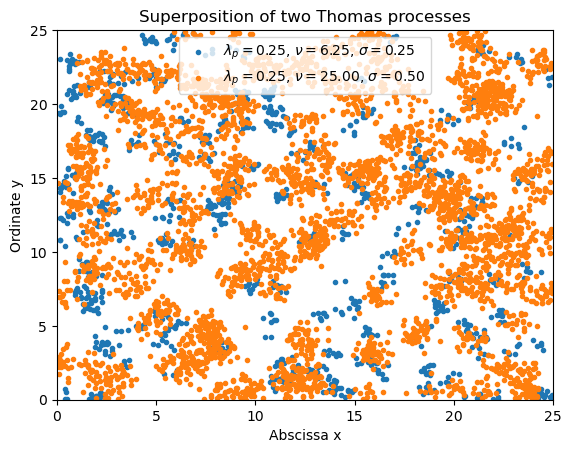

In [53]:
display_superposition([points_thomas1, points_thomas2], 
                      window=W, 
                      title="Superposition of two Thomas processes", 
                      labels=[fr'$\lambda_p = {lam_p: .2f}$, $\nu = {nu1: .2f}$, $\sigma = {sig1: .2f}$', 
                              fr'$\lambda_p = {lam_p: .2f}$, $\nu = {nu2: .2f}$, $\sigma = {sig2: .2f}$'])

In [54]:
r_values, g_values = g(points_sup, W)  # Estimating the p.c.f

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages

R[write to console]: 2: 
R[write to console]: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
R[write to console]: 
 
R[write to console]:  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages



**Theoretical expression of $g_{\text{sup}}$**

Using the assumptions from the first paragraph, we find the PCF of the superposition of two _Thomas_ processes:
$$
g_{\text{sup}}(r) = 1 + \frac{1}{4\pi\lambda_p}\left( \frac{\sigma_1^2}{(\sigma_1^2 + \sigma_2^2)^2}\exp\left(-\frac{r^2}{4\sigma_1^2}\right) + \frac{\sigma_2^2}{(\sigma_1^2 + \sigma_2^2)^2}\exp\left(-\frac{r^2}{4\sigma_2^2}\right) \right)
$$

In [55]:
def g_theo_sup(theta: list[float], r: float) -> float:
    """
    Compute the theoretical value of the PCF of a superposition of two _Thomas_ processes under two assumptions:
    - **Assumption 1**: The tree centers are generated by the same _Poisson_ process.
    - **Assumption 2**: The larger the tree, the more offspring nodes we have.

    `theta` is the vector [lam_p, sig1, sig2]
    """
    lam_p, sig1, sig2 = theta
    return 1 + (sig1**2*np.exp(-r**2/(4*sig1**2))/(sig1**2 + sig2**2)**2 + sig2**2*np.exp(-r**2/(4*sig2**2))/(sig1**2 + sig2**2)**2)/(4*np.pi*lam_p)

Let's plot it for our real $\theta$, to see if it really looks like a PCF.

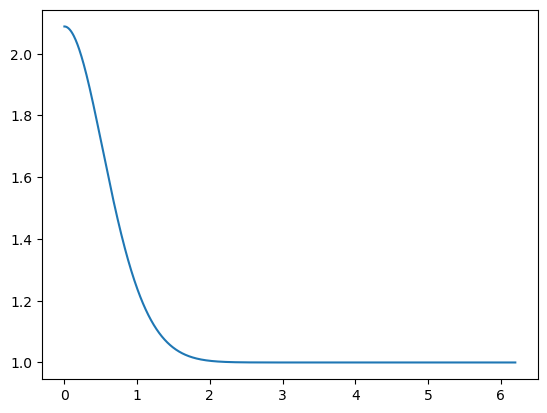

In [56]:
theta_real = [0.25, 0.3, 0.45]
r_test = np.linspace(0, 6.2, 1000)
plt.plot(r_test, g_theo_sup(theta_real, r_test))
plt.show()

In [57]:
threshold = 10  # For radii smaller than the bandwidth, the estimator explodes
r_values = r_values[threshold:]
g_values = g_values[threshold:]

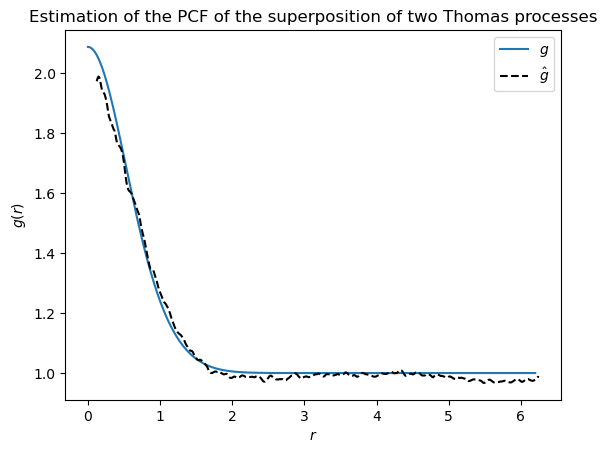

<Figure size 640x480 with 0 Axes>

In [68]:
theta_real = [0.25, 0.3, 0.45]
r_test = np.linspace(0, 6.2, 1000)
plt.plot(r_test, g_theo_sup(theta_real, r_test), label=r'$g$')
plt.plot(r_values, g_values, linestyle='--', color='black', label=r'$\hat{g}$')
plt.title('Estimation of the PCF of the superposition of two Thomas processes')
plt.xlabel(r'$r$')
plt.ylabel(r'$g(r)$')
plt.legend()
plt.show()
plt.savefig('../../img/pcf-estim-2.eps', format='eps')

In [59]:
def contrast_aux(theta):  # Auxiliary contrast function that takes theta as a parameter
    g_theo_list = g_theo_sup(theta, r_values)
    dr = r_values[1] - r_values[0]
    return contrast(g_values, g_theo_list, dr)

In [60]:
theta0 = [1, 0.25, 1.75]  # Initial guess

bounds = [(1e-6, None)]*3 # Positivity constraints

result = minimize(contrast_aux, theta0, method='L-BFGS-B', bounds=bounds)

In [61]:
result

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.0014052703290416014
        x: [ 3.616e-01  1.265e-01  4.458e-01]
      nit: 19
      jac: [ 7.684e-06  4.833e-06  8.476e-06]
     nfev: 148
     njev: 37
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [62]:
theta_real

[0.25, 0.3, 0.45]

In [63]:
def mape(y_true, y_pred):
    return abs((y_true - y_pred)/y_true)

In [64]:
mape_list = [mape(param_true, param_pred) for param_true, param_pred in zip(theta_real, result.x)]

print([f'{100*x: .2f} %' for x in mape_list])

[' 44.65 %', ' 57.85 %', ' 0.93 %']
